In [65]:
%load_ext autoreload
from scipy.stats import gaussian_kde
import sys

sys.path.append("..")
%autoreload 2
from src import *

plt.rcParams.update({'font.size': 16})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
df_x, df_y = read_dataset(stage="original")

In [41]:
def kde_iou(s1, s2, n=1024):
    x = np.linspace(min(s1.min(), s2.min()), max(s1.max(), s2.max()), n)
    k1 = gaussian_kde(s1)(x)
    k2 = gaussian_kde(s2)(x)
    return np.trapezoid(np.minimum(k1, k2), x) / np.trapezoid(np.maximum(k1, k2), x)

In [42]:
feature = "trq_margin"
series = {faulty:df_y[df_y["faulty"] == faulty]["trq_margin"] for faulty in [0, 1]}

In [49]:
iou=kde_iou(series[0],series[1])

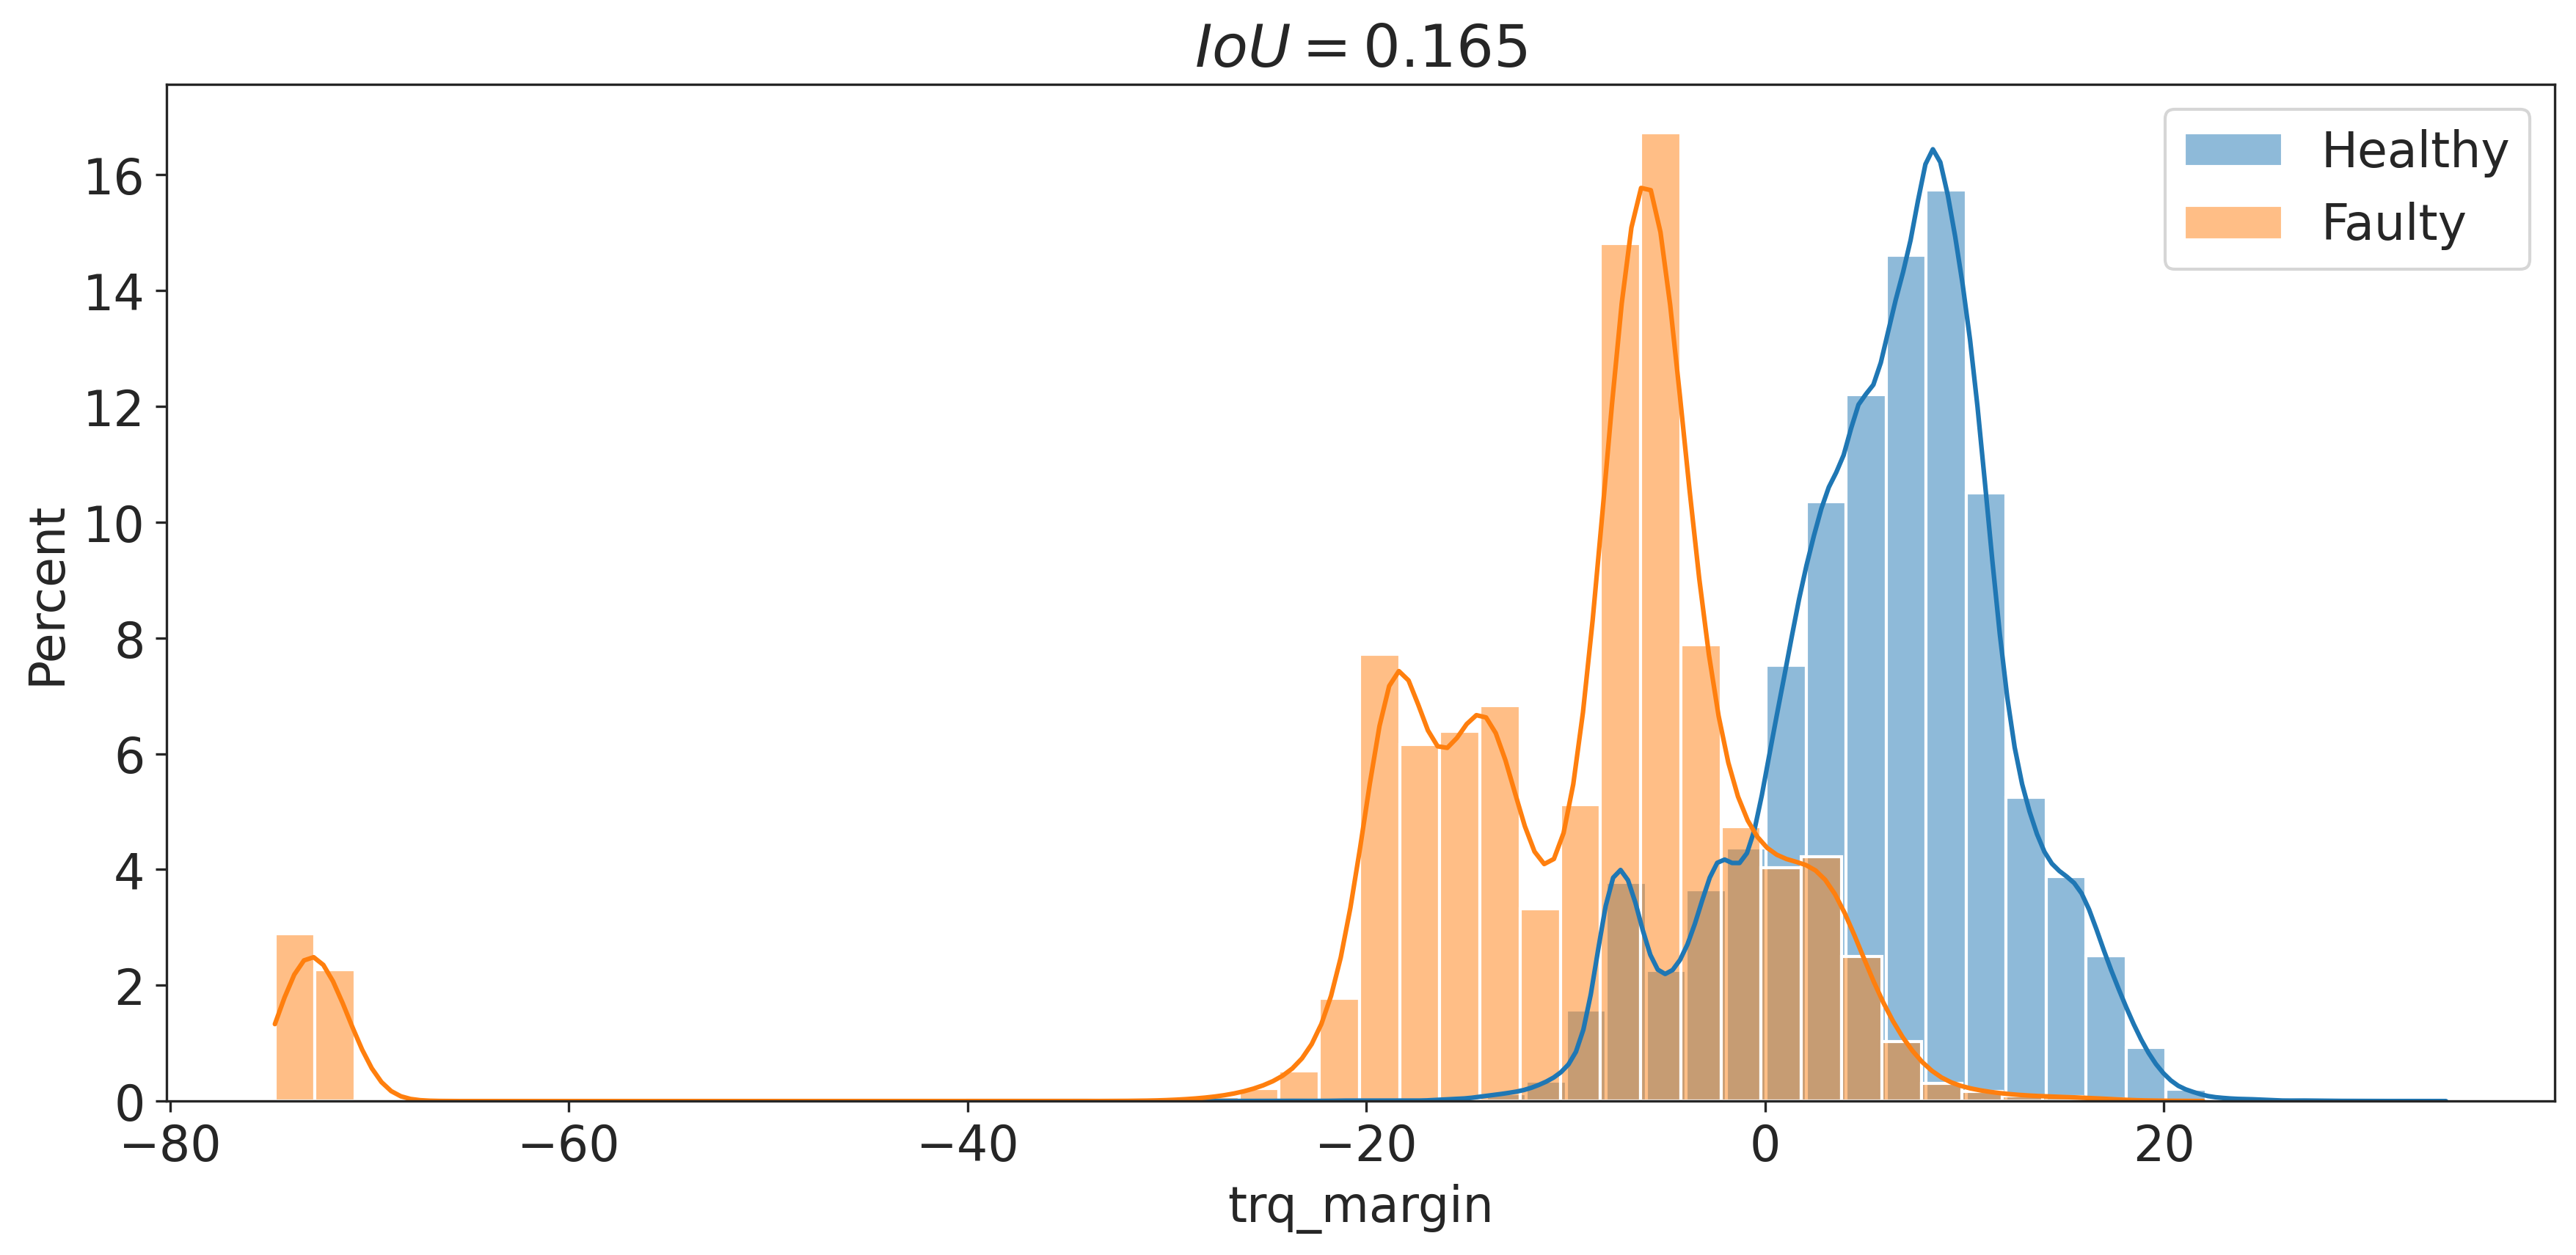

In [82]:
_, ax = plt.subplots(figsize=(14, 6), dpi=300)
sns.histplot(series[0], kde=True, bins=30, ax=ax, binwidth=2,color="tab:blue", stat="percent", label="Healthy")
sns.histplot(series[1], kde=True, bins=30, ax=ax, binwidth=2,color="tab:orange", stat="percent", label="Faulty")
ax.legend()
ax.set_title(f"$IoU = {iou:.3f}$")

pass

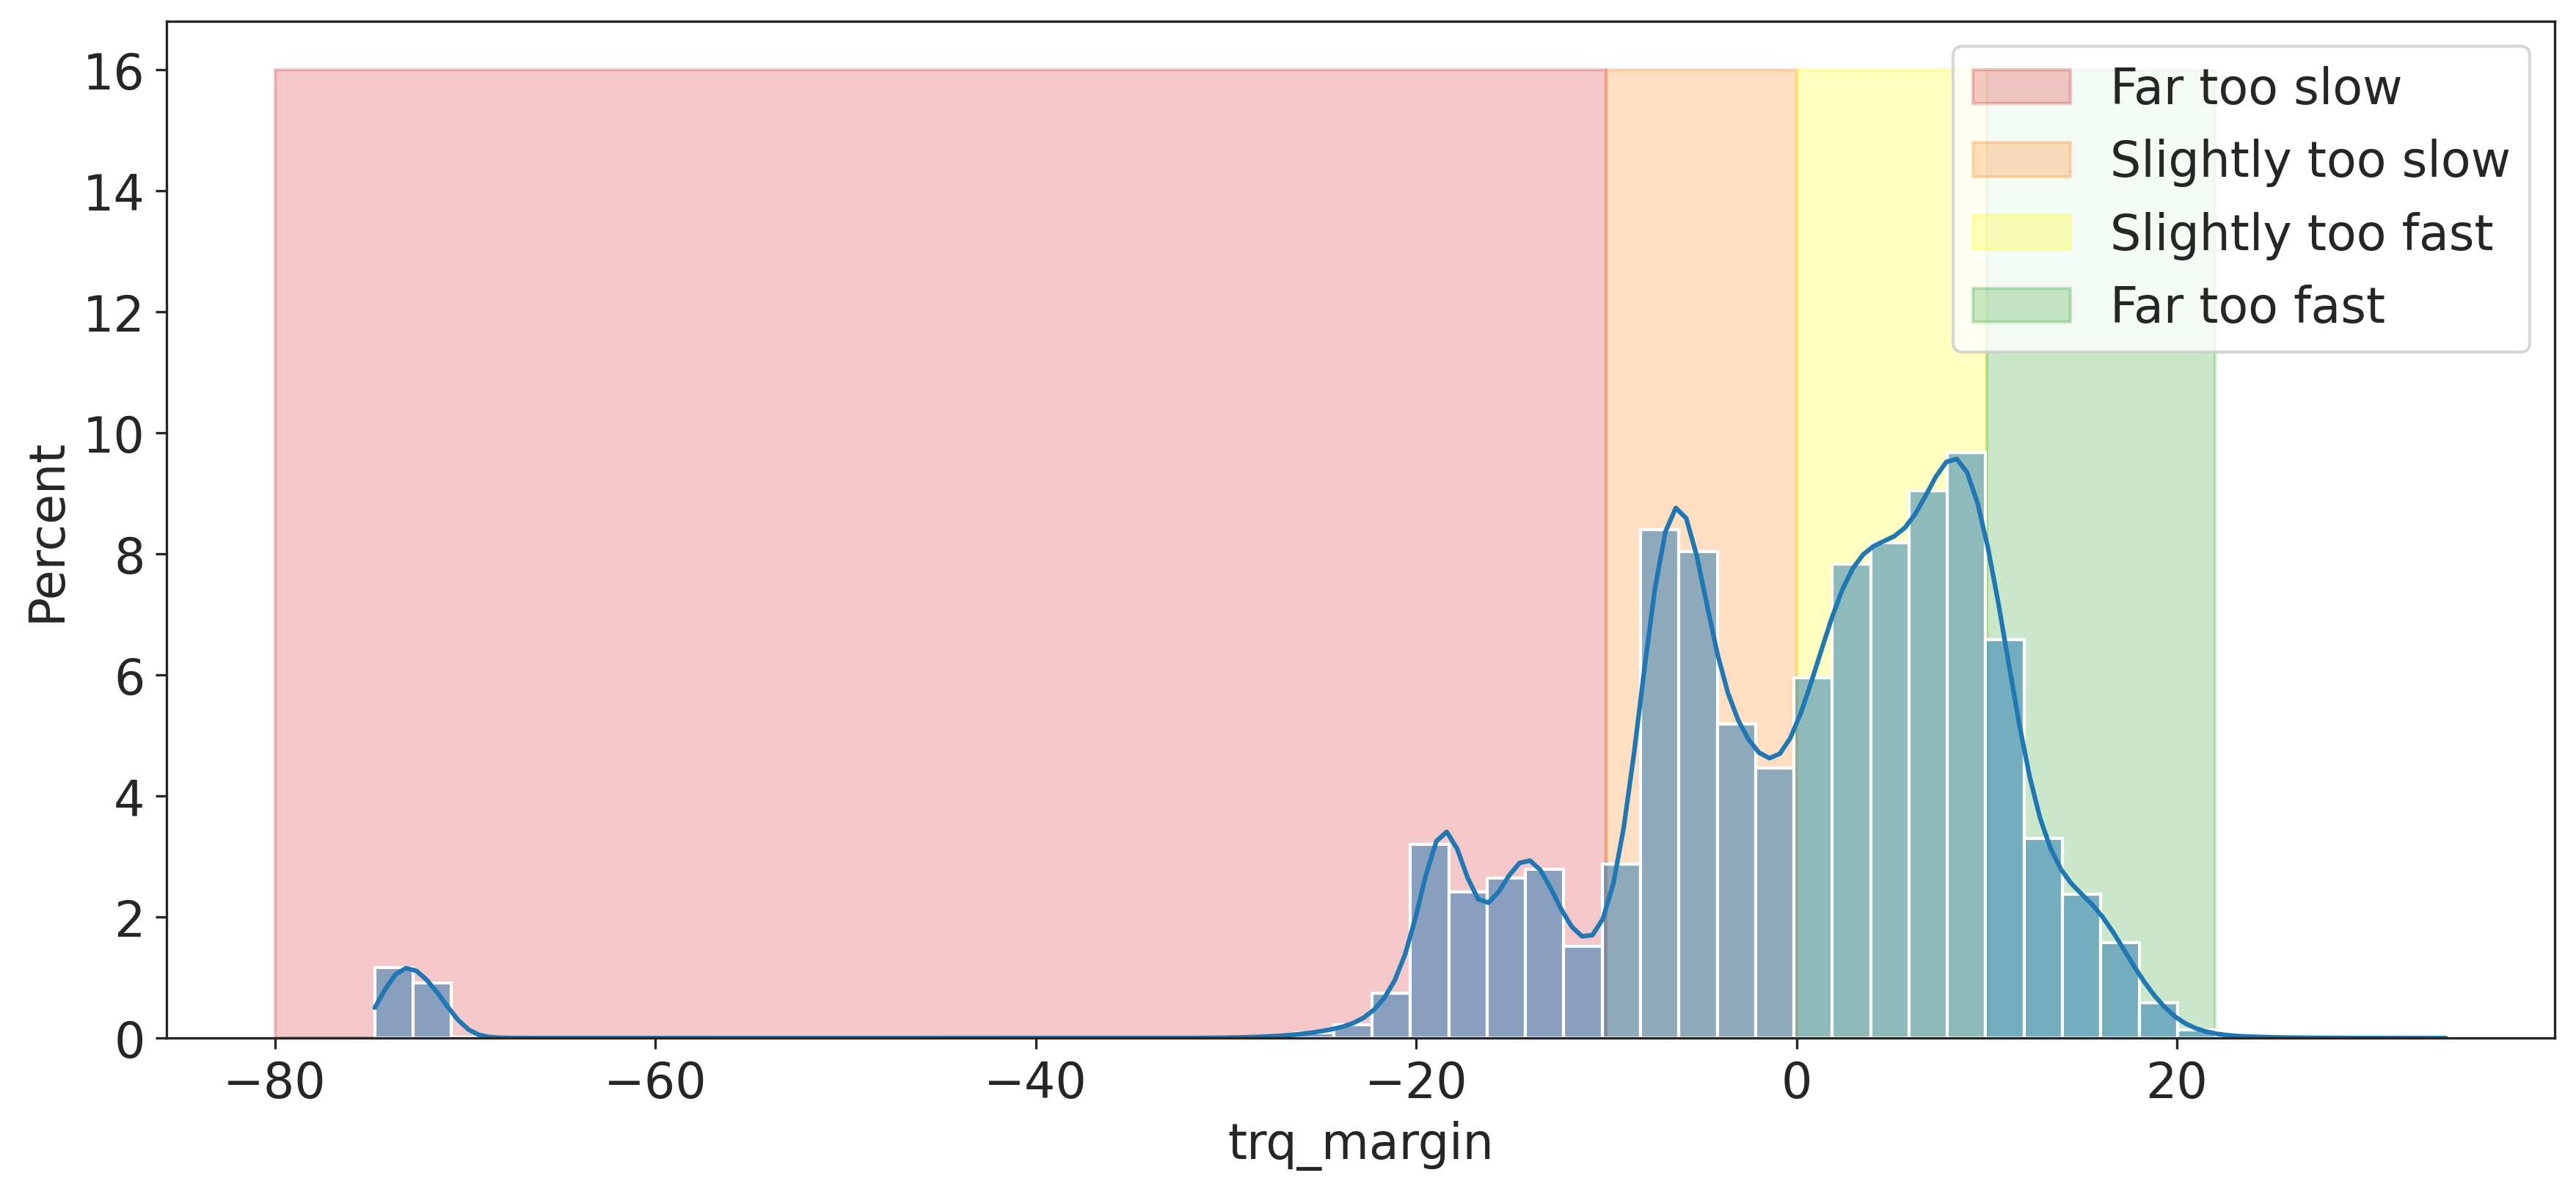

In [89]:
_, ax = plt.subplots(figsize=(14, 6), dpi=300)
ax.fill_between(range(-80, -9), 0, 16, alpha=0.25, color="tab:red", label="Far too slow")
ax.fill_between(range(-10, 1), 0, 16, alpha=0.25, color="tab:orange", label="Slightly too slow")
ax.fill_between(range(0, 11), 0, 16, alpha=0.25, color="yellow", label="Slightly too fast")
ax.fill_between(range(10, 23), 0, 16, alpha=0.25, color="tab:green", label="Far too fast")
sns.histplot(df_y["trq_margin"], kde=True, bins=30, ax=ax, binwidth=2, stat="percent")
ax.legend(loc="upper right")

The class incremental learning is not so meaningful in this context.